In [1]:
from importlib.metadata import version
import tiktoken
print("tiktoken version:", version("tiktoken"))

tiktoken version: 0.13.0


### GPT Tokenizer

In [3]:
tokenizer = tiktoken.get_encoding("gpt2")

In [5]:
text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
     "of someunknownPlace."
)
integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
print(f"integers: {integers}")

integers: [15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]


In [6]:
strings = tokenizer.decode(integers)
print(f"strings: {strings}")

strings: Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.


#### Data sampling with sliding window

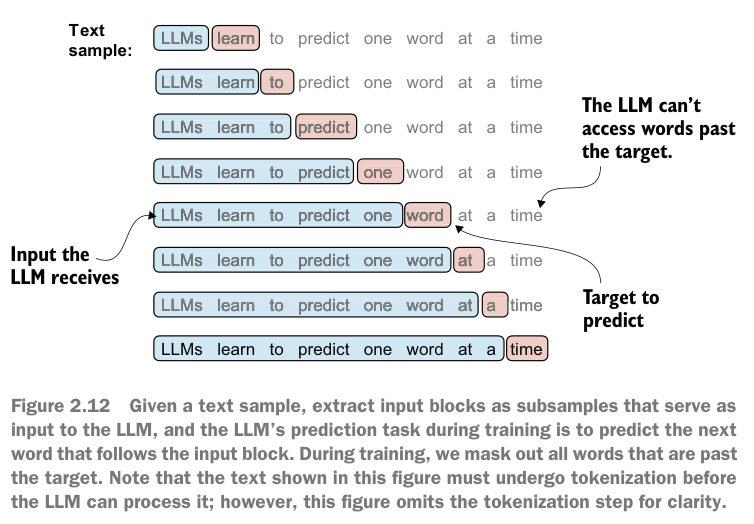

In [12]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
print(f"raw_text[:100]:\n{raw_text[:100]}")

print(f"-------\n")
# encoded text
enc_text = tokenizer.encode(raw_text)
print(f"Length of encoded text: {len(enc_text)}")
print(f"enc_text[:100]:\n{enc_text[:100]}")

raw_text[:100]:
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no g
-------

Length of encoded text: 5145
enc_text[:100]:
[40, 367, 2885, 1464, 1807, 3619, 402, 271, 10899, 2138, 257, 7026, 15632, 438, 2016, 257, 922, 5891, 1576, 438, 568, 340, 373, 645, 1049, 5975, 284, 502, 284, 3285, 326, 11, 287, 262, 6001, 286, 465, 13476, 11, 339, 550, 5710, 465, 12036, 11, 6405, 257, 5527, 27075, 11, 290, 4920, 2241, 287, 257, 4489, 64, 319, 262, 34686, 41976, 13, 357, 10915, 314, 2138, 1807, 340, 561, 423, 587, 10598, 393, 28537, 2014, 198, 198, 1, 464, 6001, 286, 465, 13476, 1, 438, 5562, 373, 644, 262, 1466, 1444, 340, 13, 314, 460, 3285, 9074, 13, 46606, 536]


In [13]:
# Creation of input-target pairs for next word prediction
enc_sample = enc_text[50:]      # Remove first 50 for demo purposes. More interesting data here.

context_size = 4
x = enc_sample[:context_size]
y = enc_sample[1:context_size + 1]

print(f"x: {x}")
print(f"y:      {y}")

x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


In [17]:
# LLM input ---> LLM prediction target
# Encoded text
for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(f"{context} ---> {desired}")


print(f"-------\n")
for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(f"{tokenizer.decode(context)} ---> {tokenizer.decode([desired])}")



[290] ---> 4920
[290, 4920] ---> 2241
[290, 4920, 2241] ---> 287
[290, 4920, 2241, 287] ---> 257
-------

 and --->  established
 and established --->  himself
 and established himself --->  in
 and established himself in --->  a


#### Dataset for batched inputs and targets

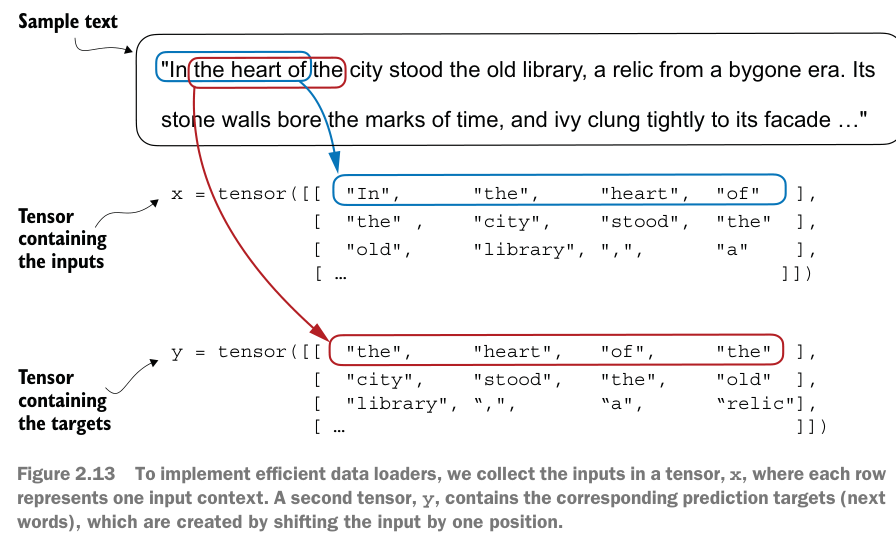

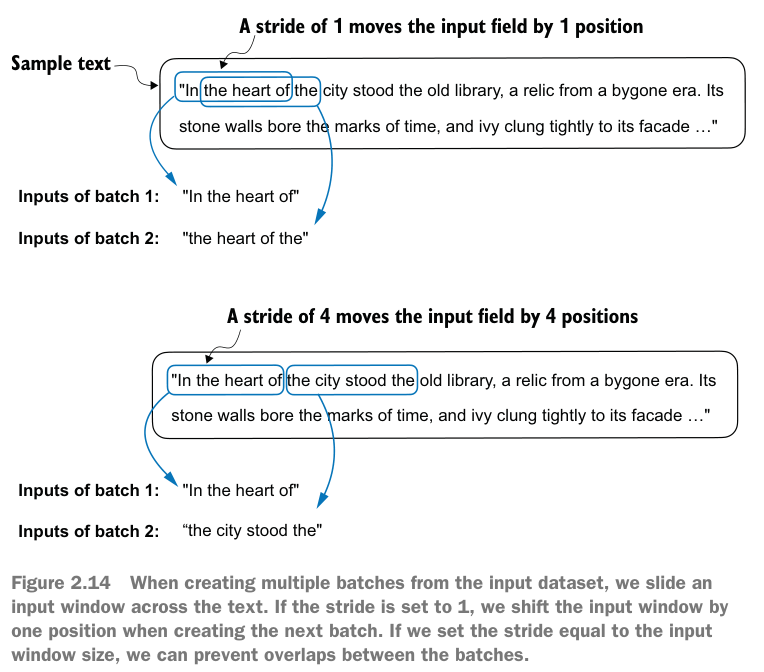

In [27]:
import torch
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.stride = stride

        # Tokenize the entire text and create input-target pairs
        token_ids = self.tokenizer.encode(txt)
        for i in range(0, len(token_ids) - self.max_length, self.stride):
            input_chunk = token_ids[i:i + self.max_length]
            target_chunk = token_ids[i + 1: i + self.max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx] 

In [28]:
def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True, num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    return DataLoader(dataset, 
                      batch_size=batch_size,
                      shuffle=shuffle,
                      drop_last=drop_last,  # drops the last batch if shorter than batch_size to prevent loss spikes
                      num_workers=num_workers
                      )

Testing dataloader...

In [31]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

dataloader = create_dataloader_v1(
    raw_text, batch_size=1, max_length=4, stride=1, shuffle=False
)

data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)
print(f"{dataloader.dataset.tokenizer.decode(first_batch[0][0].tolist())} ---> {dataloader.dataset.tokenizer.decode(first_batch[1][0].tolist())}")

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]
I HAD always --->  HAD always thought


In [32]:
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=False)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


### Token Embeddings
Converting token ids to embedding vectors...
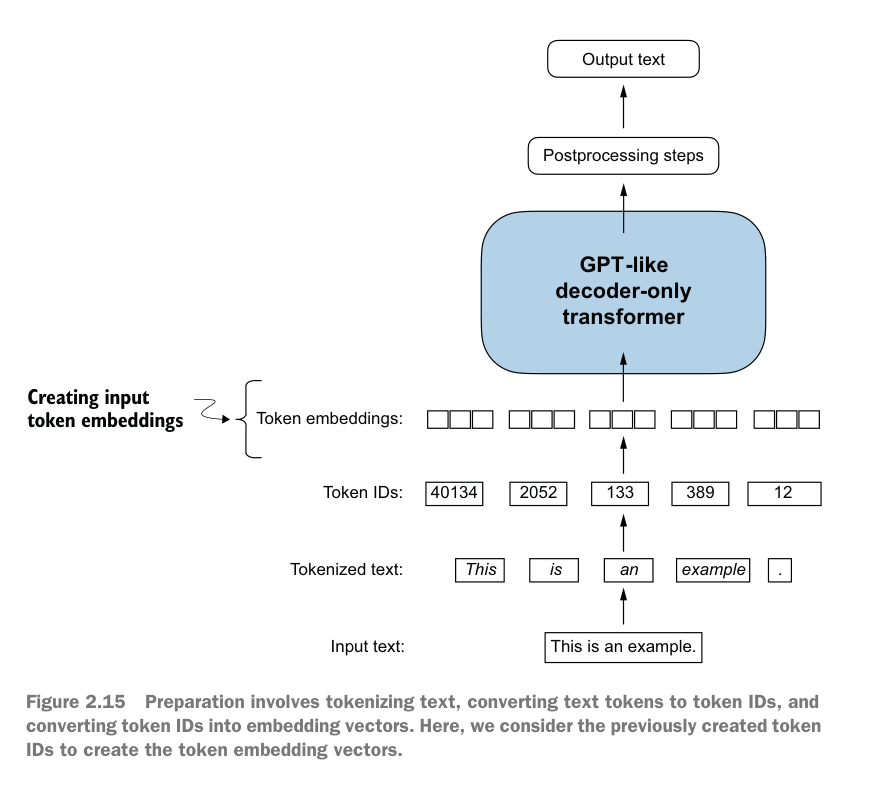

In [33]:
input_ids = torch.tensor([2, 3, 5, 1])


In [35]:
# For simplicity, suppose we have small vocab of only 6 words,
# and we want to create an embedding size of 3
vocab_size = 6
output_dim = 3

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

print(f"Embedding layer weight shape: {embedding_layer.weight.shape}")
print(embedding_layer.weight)


Embedding layer weight shape: torch.Size([6, 3])
Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [36]:
# Suppose we have a token id of 3 to obtain embedding vector
print(f"Embedding vector for token id 3: {embedding_layer(torch.tensor([3]))}")

Embedding vector for token id 3: tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


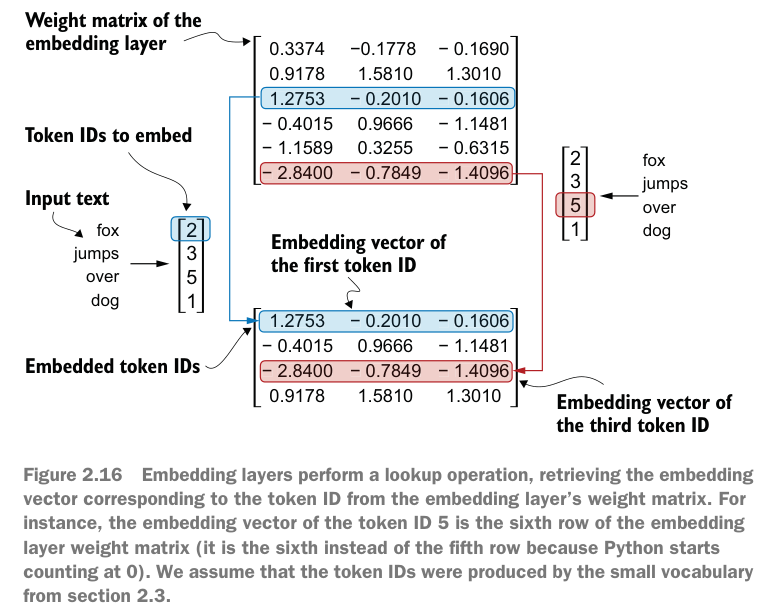


### Encoding word positions
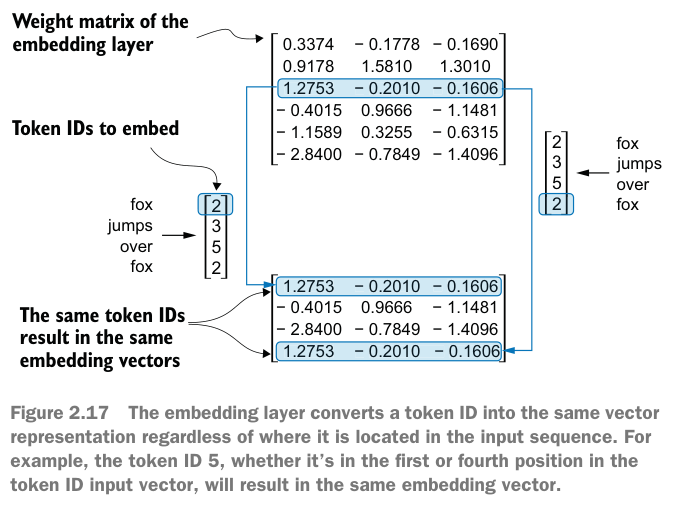

Positional embeddings combined with token embedding vector to form input embeddings of LLM
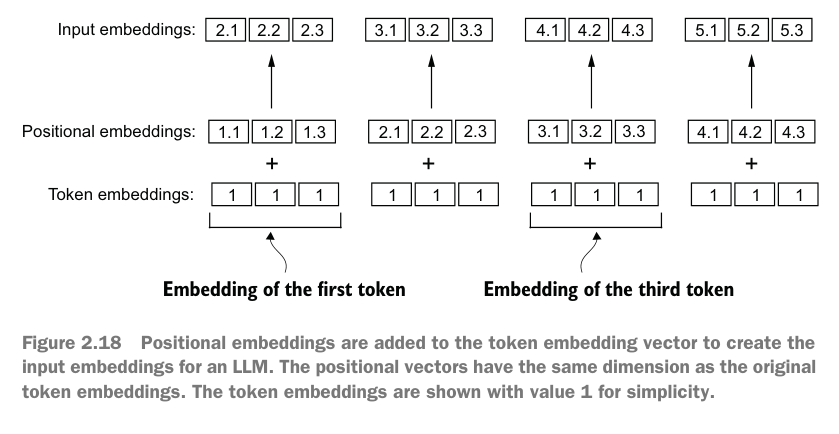

In [37]:
vocab_size = 50257
output_dim = 256

token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [39]:
max_length = 4
dataloader = create_dataloader_v1(
    raw_text, batch_size=8, max_length=max_length,
    stride=max_length, shuffle=False
)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)

print("Token IDs:\n", inputs)
print("\nInputs shape:\n", inputs.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs shape:
 torch.Size([8, 4])


In [43]:
token_embeddings = token_embedding_layer(inputs)
print(f"token_embeddings.shape: {token_embeddings.shape}")

token_embeddings.shape: torch.Size([8, 4, 256])


GPT model's absolute embedding approach
- Just need to create another embedding layer (same size as `token_embedding_layer`)

In [42]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)
pos_embeddings = pos_embedding_layer(torch.arange(context_length))

print(f"pos_embeddings.shape: {pos_embeddings.shape}")

pos_embeddings.shape: torch.Size([4, 256])


In [44]:
input_embeddings = token_embeddings + pos_embeddings
print(f"input_embeddings.shape: {input_embeddings.shape}")

input_embeddings.shape: torch.Size([8, 4, 256])


### The input-embedding pipeline
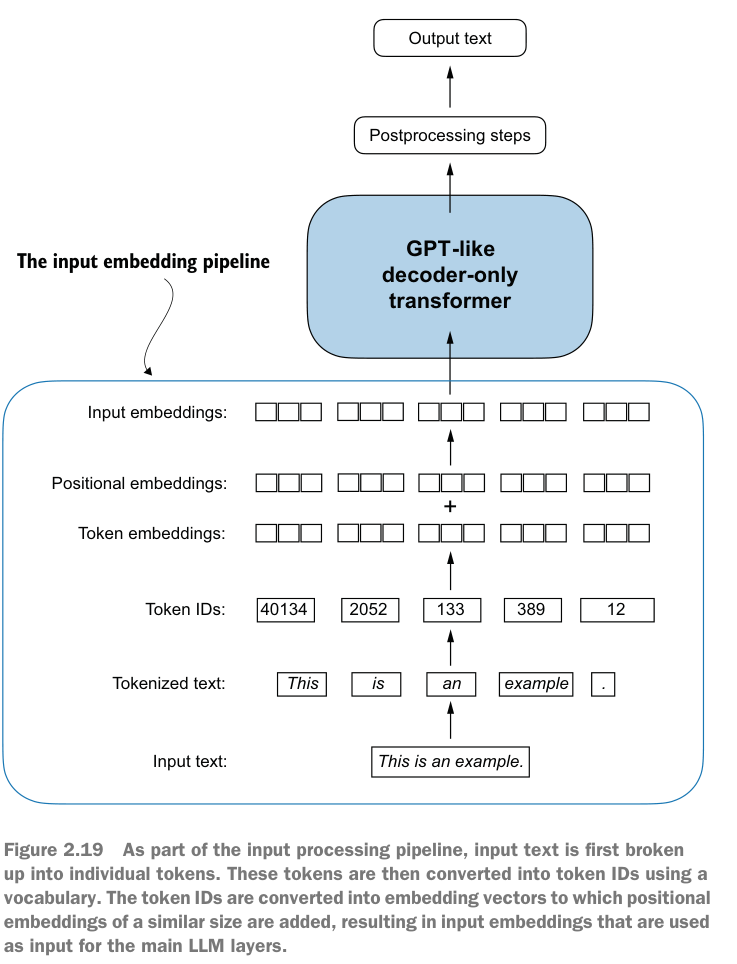